--- Dataset Overview ---
Total Records: 1500
Classes: ['neutral' 'positive' 'negative']
Average Word Count: 12.72 words

--- Sample Texts ---
1. [neutral] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
2. [neutral] I need information about the payment process.
3. [positive] The refund process was fast and convenient. I appreciate the quick response.


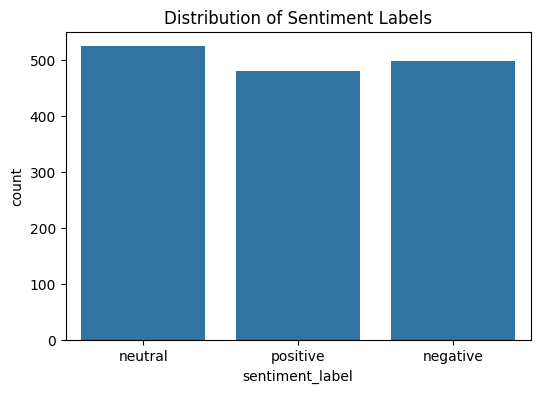

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Task 1: Dataset Understanding
df = pd.read_csv('customer_support_text_classification.csv')

print("--- Dataset Overview ---")
print(f"Total Records: {len(df)}")
print(f"Classes: {df['sentiment_label'].unique()}")
print(f"Average Word Count: {df['word_count'].mean():.2f} words")

print("\n--- Sample Texts ---")
for i in range(3):
    print(f"{i+1}. [{df['sentiment_label'].iloc[i]}] {df['customer_message'].iloc[i]}")

# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment_label')
plt.title('Distribution of Sentiment Labels')
plt.show()

In [2]:
# Task 2: Text Preprocessing (Cleaning)
def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special characters
    return text

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# Encode target labels (positive=2, neutral=1, negative=0)
encoder = LabelEncoder()
df['encoded_label'] = encoder.fit_transform(df['sentiment_label'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['encoded_label'], test_size=0.2, random_state=42
)

# Task 3 & 4: Text Vectorization (TF-IDF) & Baseline Model
print("Building Baseline Model (TF-IDF + Logistic Regression)...")

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Baseline
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# Evaluate Baseline
baseline_preds = baseline_model.predict(X_test_tfidf)
baseline_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline Accuracy: {baseline_acc:.4f}\n")
print("Baseline Classification Report:")
print(classification_report(y_test, baseline_preds, target_names=encoder.classes_))

Building Baseline Model (TF-IDF + Logistic Regression)...
Baseline Accuracy: 1.0000

Baseline Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Building Sequence Model (LSTM)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.3323 - loss: 1.1006 - val_accuracy: 0.3375 - val_loss: 1.0987
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3604 - loss: 1.0994 - val_accuracy: 0.3292 - val_loss: 1.0995
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.3385 - loss: 1.0989 - val_accuracy: 0.3292 - val_loss: 1.1001
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.1000
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3510 - loss: 1.0997 - val_accuracy: 0.3292 - val_loss: 1.1001


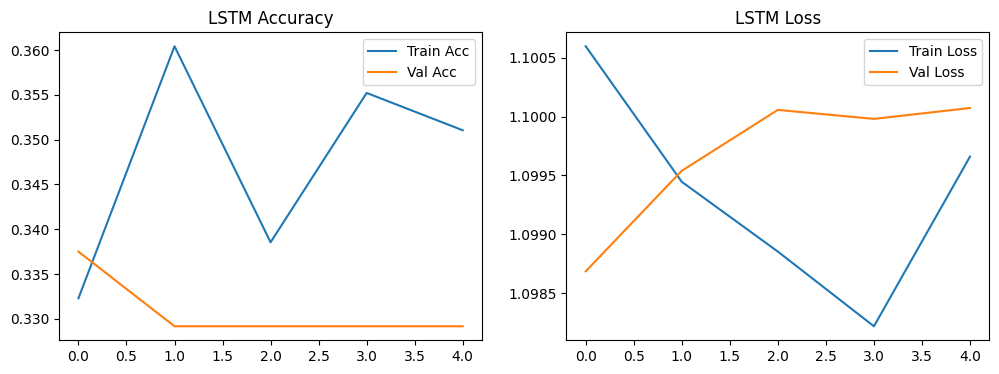

In [3]:
# Task 5: Sequence Model (LSTM)
print("Building Sequence Model (LSTM)...")

# Tokenization and Padding for Neural Network
max_words = 5000
max_len = 50 # padding to 50 words since average is low

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Build LSTM Architecture
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 classes
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# Train LSTM
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5, # Keeping it small so it runs fast
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Create results folders
os.makedirs('results', exist_ok=True)

# Plot and save evaluation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('LSTM Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.legend()

plt.savefig('results/model_evaluation.png')
plt.show()

In [4]:
# Generate Sample Predictions text file
lstm_preds = np.argmax(lstm_model.predict(X_test_pad), axis=1)

with open('results/sample_predictions.txt', 'w') as f:
    f.write("Sample Predictions comparing Baseline (TF-IDF) vs LSTM\n")
    f.write("="*60 + "\n\n")

    for i in range(10): # Save first 10 test predictions
        original_text = X_test.iloc[i]
        actual_label = encoder.inverse_transform([y_test.iloc[i]])[0]
        base_pred_label = encoder.inverse_transform([baseline_preds[i]])[0]
        lstm_pred_label = encoder.inverse_transform([lstm_preds[i]])[0]

        f.write(f"Text: {original_text}\n")
        f.write(f"Actual: {actual_label} | Baseline Pred: {base_pred_label} | LSTM Pred: {lstm_pred_label}\n")
        f.write("-" * 60 + "\n")

print("Saved sample predictions to results/sample_predictions.txt")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Saved sample predictions to results/sample_predictions.txt
